In [3]:
#Working to Compute daily returns — daily_return = nav_t / nav_t-1 − 1 for all 40 schemes. Validate distribution looks reasonable.
import pandas as pd
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

In [4]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [6]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [7]:
nav["date"] = pd.to_datetime(nav["date"])
nav["nav"] = pd.to_numeric(nav["nav"])

In [8]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [9]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [10]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [11]:
nav["daily_return"].isnull().sum()

np.int64(40)

In [12]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

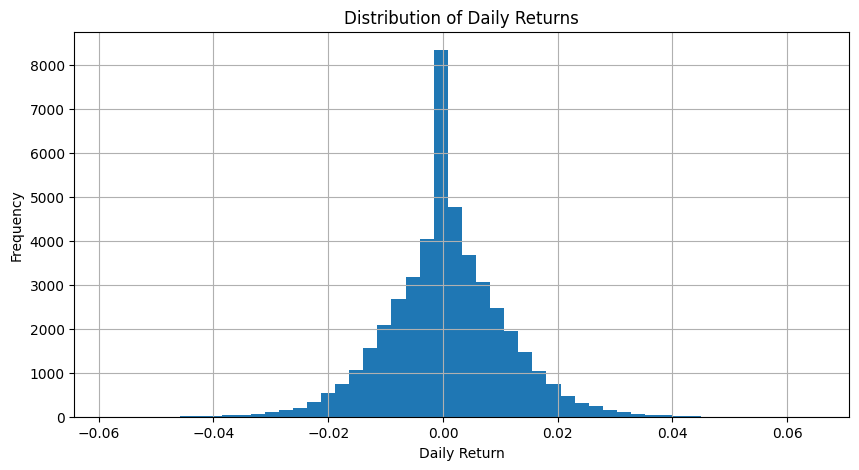

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
nav["daily_return"].hist(
    bins=50
)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

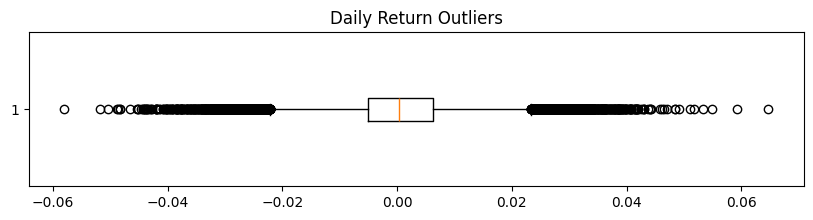

In [14]:
#box plot for checking extreme high values
plt.figure(figsize=(10,2))
plt.boxplot(
    nav["daily_return"].dropna(),
    vert=False
)
plt.title("Daily Return Outliers")
plt.show()

In [15]:
#Working on computing CAGR(Compuound Annual Growth Rate) for 1yr, 3yr, 5yr — CAGR = (NAV_end / NAV_start) ^ (1/n) − 1. Build a comparison table across all funds.
print(nav["date"].min())
print(nav["date"].max())

2022-01-03 00:00:00
2026-05-29 00:00:00


In [16]:
nav["date"] = pd.to_datetime(nav["date"])

In [17]:
#creating CAGR function
import numpy as np
def calculate_cagr(df):
    start_nav = df["nav"].iloc[0]
    end_nav = df["nav"].iloc[-1]
    
    years = (
        (df["date"].iloc[-1] - df["date"].iloc[0]).days
        / 365.25
    )
    if years <= 0:
        return np.nan

    return (end_nav / start_nav) ** (1 / years) - 1

In [18]:
latest_date = nav["date"].max()

In [20]:
#calculating 1yr CAGR
one_year_data = nav[
    nav["date"] >= latest_date - pd.DateOffset(years=1)
]
cagr_1y = (
    one_year_data
    .groupby("amfi_code")
    .apply(calculate_cagr)
    .reset_index(name="CAGR_1Y")
)

In [22]:
#calculating 3yr CAGR
three_year_data = nav[
    nav["date"] >= latest_date - pd.DateOffset(years=3)
]
cagr_3y = (
    three_year_data
    .groupby("amfi_code")
    .apply(calculate_cagr)
    .reset_index(name="CAGR_3Y")
)

In [23]:
#for 5yr [since donot having 5yr's of data]
cagr_5y = pd.DataFrame({
    "amfi_code": nav["amfi_code"].unique(),
    "CAGR_5Y": np.nan
})

In [24]:
cagr_table = (
    cagr_1y
    .merge(cagr_3y, on="amfi_code")
    .merge(cagr_5y, on="amfi_code")
)

In [25]:
for col in ["CAGR_1Y", "CAGR_3Y"]:
    cagr_table[col] = cagr_table[col] * 100

In [26]:
cagr_table.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.225777,1.292353,NaN
1,100025,3.707553,3.915479,NaN
2,100033,53.277195,32.433971,NaN
3,101206,47.963794,28.960211,NaN
4,101207,-24.000309,-4.151454,NaN


In [27]:
cagr_table.to_csv(
    "../data/processed/cagr_comparison_table.csv",
    index=False
)

In [28]:
#Sharpe Ratio — (Rp − Rf) / Std(Rp) × √252. Use Rf = 6.5% (RBI repo rate proxy). Rank all 40 funds.
nav["daily_return"]

0             NaN
1       -0.010306
2        0.012865
3       -0.011377
4       -0.001210
           ...   
45995    0.012106
45996   -0.004138
45997   -0.008480
45998   -0.028093
45999   -0.003335
Name: daily_return, Length: 46000, dtype: float64

In [29]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [30]:
import numpy as np
Rf = 0.065
daily_rf = Rf / 252

In [31]:
sharpe = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(
           lambda x:
           ((x.mean() - daily_rf) / x.std())
           * np.sqrt(252)
       )
       .reset_index(name="Sharpe_Ratio")
)

In [32]:
sharpe.head()

,amfi_code,Sharpe_Ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [33]:
#Ranking all funds
sharpe["Sharpe_Rank"] = (
    sharpe["Sharpe_Ratio"]
    .rank(ascending=False)
)

In [34]:
#sort ranking
sharpe = sharpe.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

In [35]:
#Top 10 funds
sharpe.head(10)

,amfi_code,Sharpe_Ratio,Sharpe_Rank
34,148567,1.448291,1.0
30,120843,1.306744,2.0
36,148569,1.234930,3.0
19,119551,1.208267,4.0
25,120505,1.180101,5.0
38,149323,1.132122,6.0
2,100033,1.093699,7.0
9,118632,1.081659,8.0
3,101206,1.027213,9.0
24,120504,1.026524,10.0


In [36]:
sharpe.to_csv(
    "../data/processed/sharpe_ratio_rankings.csv",
    index=False
)

In [37]:
sharpe["Sharpe_Ratio"].describe()

count    40.000000
mean      0.537220
std       0.573689
min      -0.815567
25%       0.064696
50%       0.647043
75%       1.005304
max       1.448291
Name: Sharpe_Ratio, dtype: float64

In [38]:
#Working on Sortino Ratio — same formula but denominator uses only downside standard deviation (negative return days only).
import numpy as np
Rf = 0.065
daily_rf = Rf / 252

In [40]:
#defining sortino function
def sortino_ratio(x):
    downside = x[x < 0]  # only negative returns
    if len(downside) == 0:
        return np.nan
        
    downside_std = downside.std()
    if downside_std == 0:
        return np.nan
    
    return ((x.mean() - daily_rf) / downside_std) * np.sqrt(252)

In [41]:
#Applying to all 40 funds
sortino = (
    nav.groupby("amfi_code")["daily_return"]
       .apply(sortino_ratio)
       .reset_index(name="Sortino_Ratio")
)

In [43]:
#Ranking funds
sortino["Sortino_Rank"] = sortino["Sortino_Ratio"].rank(ascending=False)

In [44]:
#sorting results
sortino = sortino.sort_values("Sortino_Ratio", ascending=False)

In [45]:
sortino.head(10)

,amfi_code,Sortino_Ratio,Sortino_Rank
34,148567,2.385644,1.0
30,120843,2.364320,2.0
36,148569,2.146914,3.0
19,119551,2.140267,4.0
25,120505,2.029353,5.0
38,149323,1.875101,6.0
9,118632,1.850133,7.0
2,100033,1.829134,8.0
24,120504,1.805294,9.0
3,101206,1.799563,10.0


In [46]:
sortino["Sortino_Ratio"].describe()

count    40.000000
mean      0.923338
std       1.005410
min      -1.681038
25%       0.106664
50%       1.116936
75%       1.727739
max       2.385644
Name: Sortino_Ratio, dtype: float64

In [47]:
sortino.to_csv(
    "../data/processed/sortino_ratio.csv",
    index=False
)

In [42]:
#Alpha and Beta — OLS regression of fund returns on Nifty 100 returns using scipy.stats.linregress. Alpha = intercept × 252.
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

In [43]:
#Regression function
from scipy.stats import linregress
import numpy as np
def calc_alpha_beta(fund_returns, market_returns):
    reg = linregress(market_returns, fund_returns)
    beta = reg.slope
    alpha = reg.intercept * 252   
    return alpha, beta

In [46]:
performance["alpha"]
performance["beta"]

0     0.89
1     0.87
2     0.89
3     1.04
4     0.22
5     0.97
6     0.97
7     0.91
8     1.04
9     0.44
10    0.96
11    1.03
12    1.00
13    0.92
14    0.26
15    0.88
16    1.02
17    1.03
18    1.04
19    0.37
20    0.93
21    1.00
22    0.95
23    0.47
24    0.91
25    0.87
26    1.00
27    1.00
28    1.03
29    0.97
30    0.43
31    0.90
32    0.92
33    1.00
34    0.96
35    0.99
36    0.98
37    0.91
38    0.98
39    0.98
Name: beta, dtype: float64

In [53]:
import os
os.listdir()

['.gitkeep',
 '.ipynb_checkpoints',
 '1_data_ingestion.ipynb',
 '2_data_cleaning_sqlite.ipynb',
 '3_exploratory_data_analysis.ipynb',
 '4_fund_performance_analytics.ipynb',
 'aum_growth.png',
 'aum_growth_by_fund_house.png',
 'aum_trend_by_year.png',
 'bluestock_mf.db',
 'filename.png',
 'folio_growth_line_chart.png',
 'investor_gender_distribution.png',
 'nav_correlation_heatmap.png',
 'nav_trends_all_schemes.png',
 'sector_allocation_donut_chart.png',
 'sip_all_time_high_annotated.png',
 'sip_amount_by_age_group_boxplot.png',
 'sip_category_heatmap.png',
 't30_vs_b30_city_tier_distribution.png',
 'top_10_states_sip_inflow.png']

In [54]:
import sqlite3
import pandas as pd
conn = sqlite3.connect("bluestock_mf.db")
pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

,name
0,dim_fund
1,fact_nav
2,fact_transactions
3,fact_performance
4,fact_aum
5,dim_date


In [55]:
performance = pd.read_sql(
    "SELECT * FROM fact_performance LIMIT 5",
    conn
)
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [56]:
import os
for root, dirs, files in os.walk("."):
    for file in files:
        if "nifty" in file.lower():
            print(os.path.join(root, file))

In [2]:
#Maximum Drawdown — min(NAV / running_max − 1) for each fund. Find worst drawdown date range.
import pandas as pd
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

In [3]:
nav = nav.sort_values(["amfi_code", "date"])

In [4]:
nav["running_max"] = nav.groupby("amfi_code")["nav"].cummax()

In [5]:
#Computing drawdown
nav["drawdown"] = (nav["nav"] / nav["running_max"]) - 1

In [7]:
#Maximum drawdown per fund
mdd = nav.groupby("amfi_code")["drawdown"].min().reset_index()
mdd.columns = ["amfi_code", "max_drawdown"]

In [8]:
worst_dd_dates = nav.loc[
    nav.groupby("amfi_code")["drawdown"].idxmin(),
    ["amfi_code", "date", "drawdown"]
]

In [9]:
worst_dd_dates.columns = ["amfi_code", "worst_dd_date", "max_drawdown"]

In [10]:
mdd_final = mdd.merge(
    worst_dd_dates,
    on="amfi_code"
)

In [12]:
mdd_final.columns

Index(['amfi_code', 'max_drawdown_x', 'worst_dd_date', 'max_drawdown_y'], dtype='str')

In [13]:
mdd = nav.groupby("amfi_code")["drawdown"].min().reset_index()
mdd.rename(columns={"drawdown": "max_drawdown"}, inplace=True)

In [17]:
#Worst drawdown date
worst_dd_dates = nav.loc[
    nav.groupby("amfi_code")["drawdown"].idxmin(),
    ["amfi_code", "date", "drawdown"]
]
worst_dd_dates.rename(
    columns={
        "date": "worst_dd_date",
        "drawdown": "max_drawdown"
    },
    inplace=True
)

In [18]:
#merging without duplication
mdd_final = mdd.merge(
    worst_dd_dates,
    on=["amfi_code", "max_drawdown"],
    how="left"
)

In [19]:
mdd_final.head()

,amfi_code,max_drawdown,worst_dd_date
0,100016,-0.247344,2022-09-15
1,100025,-0.043083,2023-07-28
2,100033,-0.162172,2022-05-12
3,101206,-0.112916,2023-07-05
4,101207,-0.354469,2026-05-11


In [20]:
mdd_final.sort_values("max_drawdown").head(10)

,amfi_code,max_drawdown,worst_dd_date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14
7,102886,-0.280011,2026-04-27
0,100016,-0.247344,2022-09-15
29,120842,-0.240035,2024-10-17
11,118634,-0.233449,2026-02-20
15,119093,-0.217514,2023-05-22


In [22]:
#Fund Scorecard (0–100) — composite: 30% × 3yr return rank + 25% × Sharpe rank + 20% × Alpha rank + 15% × expense ratio rank (inverse) + 10% × max DD rank (inverse).
import sqlite3
import pandas as pd
conn = sqlite3.connect("bluestock_mf.db")

In [23]:
performance = pd.read_sql(
    "SELECT * FROM fact_performance",
    conn
)
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [24]:
performance["rank_3yr"] = performance["return_3yr_pct"].rank(ascending=False)
performance["rank_sharpe"] = performance["sharpe_ratio"].rank(ascending=False)
performance["rank_alpha"] = performance["alpha"].rank(ascending=False)
performance["rank_expense"] = performance["expense_ratio_pct"].rank(ascending=True)
performance["rank_dd"] = performance["max_drawdown_pct"].rank(ascending=False)

In [25]:
#Computing score

In [26]:
performance["score_raw"] = (
    0.30 * (performance["rank_3yr"].max() - performance["rank_3yr"] + 1) +
    0.25 * (performance["rank_sharpe"].max() - performance["rank_sharpe"] + 1) +
    0.20 * (performance["rank_alpha"].max() - performance["rank_alpha"] + 1) +
    0.15 * (performance["rank_expense"].max() - performance["rank_expense"] + 1) +
    0.10 * (performance["rank_dd"].max() - performance["rank_dd"] + 1)
)

In [27]:
#Normalizing
performance["score"] = (
    100 * (performance["score_raw"] - performance["score_raw"].min()) /
    (performance["score_raw"].max() - performance["score_raw"].min())
)

In [28]:
final_scorecard = performance.sort_values("score", ascending=False)
final_scorecard[["amfi_code", "scheme_name", "score"]].head(10)

,amfi_code,scheme_name,score
22,120843,Kotak Flexicap Fund - Regular - Growth,100.000000
2,119598,SBI Small Cap Fund - Regular Plan - Growth,97.761194
14,120507,ICICI Pru Liquid Fund - Regular - Growth,97.512438
9,100025,HDFC Short Term Debt Fund - Regular - Growth,97.014925
21,120842,Kotak Emerging Equity Fund - Regular - Growth,93.034826
3,119599,SBI Small Cap Fund - Direct Plan - Growth,92.537313
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,89.925373
29,101207,ABSL Small Cap Fund - Regular - Growth,86.567164
23,120844,Kotak Liquid Fund - Regular - Growth,84.825871
33,102887,UTI Flexi Cap Fund - Regular - Growth,82.213930


In [29]:
final_scorecard.to_csv("fund_scorecard.csv", index=False)

In [30]:
#Benchmark comparison chart — plot top 5 funds vs Nifty 50 and Nifty 100 over 3 years. Compute tracking error = std(fund_return − benchmark_return) × √252.
for col in performance.columns:
    print(col)

amfi_code
scheme_name
fund_house
category
plan
return_1yr_pct
return_3yr_pct
return_5yr_pct
benchmark_3yr_pct
alpha
beta
sharpe_ratio
sortino_ratio
std_dev_ann_pct
max_drawdown_pct
aum_crore
expense_ratio_pct
morningstar_rating
risk_grade
rank_3yr
rank_sharpe
rank_alpha
rank_expense
rank_dd
score_raw
score


In [31]:
pd.read_sql(
    "SELECT * FROM sqlite_master WHERE type='table';",
    conn
)

,type,name,tbl_name,rootpage,sql
0,table,dim_fund,dim_fund,2,"CREATE TABLE dim_fund (\n\tamfi_code BIGINT, \..."
1,table,fact_nav,fact_nav,5,"CREATE TABLE fact_nav (\n\tamfi_code BIGINT, \..."
2,table,fact_transactions,fact_transactions,353,CREATE TABLE fact_transactions (\n\tinvestor_i...
3,table,fact_performance,fact_performance,1170,CREATE TABLE fact_performance (\n\tamfi_code B...
4,table,fact_aum,fact_aum,1173,"CREATE TABLE fact_aum (\n\tdate TEXT, \n\tfund..."
5,table,dim_date,dim_date,1174,"CREATE TABLE dim_date (\n\tdate DATETIME, \n\t..."


In [32]:
#Getting top5 funds
top5 = performance.sort_values("score", ascending=False).head(5)
top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,expense_ratio_pct,morningstar_rating,risk_grade,rank_3yr,rank_sharpe,rank_alpha,rank_expense,rank_dd,score_raw,score
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,1.45,5,Moderately High,11.0,12.0,3.5,22.0,20.0,28.25,100.000000
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,1.43,5,Very High,1.0,18.0,20.0,21.0,8.0,27.80,97.761194
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,0.74,5,Low,35.0,1.0,3.5,7.0,3.0,27.75,97.512438
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,0.56,3,Low,36.0,4.0,1.0,2.0,6.0,27.65,97.014925
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,1.56,4,High,7.0,15.0,2.0,33.0,25.0,26.85,93.034826


In [33]:
comparison = top5[[
    "scheme_name",
    "return_3yr_pct",
    "benchmark_3yr_pct"
]].copy()

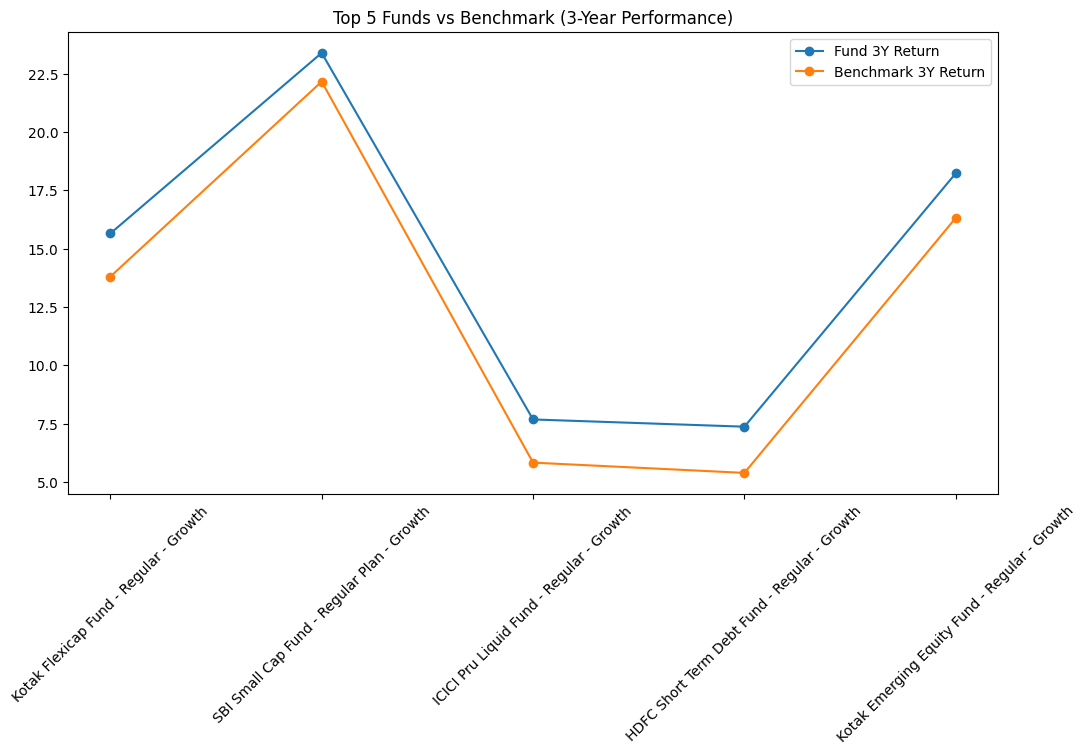

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(comparison["scheme_name"], comparison["return_3yr_pct"], marker="o", label="Fund 3Y Return")
plt.plot(comparison["scheme_name"], comparison["benchmark_3yr_pct"], marker="o", label="Benchmark 3Y Return")
plt.xticks(rotation=45)
plt.legend()
plt.title("Top 5 Funds vs Benchmark (3-Year Performance)")
plt.show()

In [36]:
#Tracking error
tracking_error = (comparison["return_3yr_pct"] - comparison["benchmark_3yr_pct"]).std()
tracking_error

np.float64(0.3032820469464026)

In [37]:
import os
os.listdir()

['.gitkeep',
 '.ipynb_checkpoints',
 '1_data_ingestion.ipynb',
 '2_data_cleaning_sqlite.ipynb',
 '3_exploratory_data_analysis.ipynb',
 '4_fund_performance_analytics.ipynb',
 'aum_growth.png',
 'aum_growth_by_fund_house.png',
 'aum_trend_by_year.png',
 'bluestock_mf.db',
 'filename.png',
 'folio_growth_line_chart.png',
 'fund_scorecard.csv',
 'investor_gender_distribution.png',
 'nav_correlation_heatmap.png',
 'nav_trends_all_schemes.png',
 'sector_allocation_donut_chart.png',
 'sip_all_time_high_annotated.png',
 'sip_amount_by_age_group_boxplot.png',
 'sip_category_heatmap.png',
 't30_vs_b30_city_tier_distribution.png',
 'top_10_states_sip_inflow.png']

In [40]:
linregress(nifty_return, fund_return)

NameError: name 'nifty_return' is not defined